In [1]:
import numpy as np
import pandas as pd

Q1. Sales Data Analysis
You are a data analyst at an e-commerce company. Your task is to analyze sales data, clean and process it, perform statistical analysis, and generate visual insights to help the business make informed decisions.

Use your roll number as the random seed to generate unique data for each study.

In [2]:
roll_number = 102316045
np.random.seed(roll_number)

Part I: Randomized Sales Data Generation (NumPy)
Initialize Random Seed

Generate Sales Data:

Create a NumPy array of random sales data for 12 months (shape = (12, 4)), where each column represents a product category:
Electronics, Clothing, Home & Kitchen, Sports.
Sales values should be between 1000 and 5000 units per month.
The range should be randomized using the seed.
Convert to DataFrame

Convert the cleaned NumPy array into a Pandas DataFrame with:
Columns: Electronics, Clothing, Home & Kitchen, Sports
Index: Months from Jan to Dec an to Dec

In [3]:
sales = np.random.randint(1000, 5001, size=(12,4))
print(sales)


[[3142 3617 4240 3671]
 [3146 4737 1772 2529]
 [1227 2087 3940 1925]
 [3355 2066 2691 2307]
 [4569 2182 4171 3132]
 [4471 4560 3531 4594]
 [3482 1699 2463 1352]
 [1174 2120 2760 4114]
 [4811 1549 1905 4640]
 [1280 1603 2336 2023]
 [4336 1487 2713 2634]
 [3207 3619 1663 2655]]


In [4]:
months=['jan','feb','mar','apr','may','june','july','aug','sep','oct','nov','dec']
colm = ['electronics','clothing','home & kitchen','sports']
sales_df = pd.DataFrame(sales, columns=colm, index=months)
sales_df


,electronics,clothing,home & kitchen,sports
jan,3142,3617,4240,3671
feb,3146,4737,1772,2529
mar,1227,2087,3940,1925
apr,3355,2066,2691,2307
may,4569,2182,4171,3132
june,4471,4560,3531,4594
july,3482,1699,2463,1352
aug,1174,2120,2760,4114
sep,4811,1549,1905,4640
oct,1280,1603,2336,2023


Part II: Data Manipulation and Analysis
1. Display the First 5 Rows and Summary Statistics
We first examine the initial rows and descriptive statistics of the sales data. This helps us understand the distribution, mean, minimum, maximum, and standard deviation of sales across categories.

2. Calculate Total Sales
Total sales per category are calculated by summing up all sales values in each column.
Total sales per month are calculated by summing across the row (i.e., across all four categories).
This gives us a clear idea of which category and which months performed the best in terms of sales.

3. Average Sales Growth Between Consecutive Months
We calculate the month-to-month percentage change for each category using pct_change(). Then, we find the average of these monthly changes for each product category to understand overall growth trends.

The result is expressed as a percentage.

4. Add Total Sales and Growth Rate Columns
Total Sales: A new column that adds up all four product categories per month.
Growth Rate (%): A new column that calculates the percentage change in Total Sales compared to the previous month.
These new columns help to observe overall sales performance trends.

5. Apply a Randomized Discount
Based on the roll number:

If the roll number is even, we apply a 10% discount to the Electronics category


In [5]:
print(sales_df.head(), '\n')
print(sales_df.describe(), '\n')
print(sales_df.sum(), '\n')
print(sales_df.sum(axis=1))


     electronics  clothing  home & kitchen  sports
jan         3142      3617            4240    3671
feb         3146      4737            1772    2529
mar         1227      2087            3940    1925
apr         3355      2066            2691    2307
 ay         4569      2182            4171    3132

       electronics     clothing  home & kitchen       sports
count    12.000000    12.000000       12.000000    12.000000
mean   3183.333333  2610.500000     2848.750000  2964.666667
std    1319.978260  1190.199563      917.465692  1074.719611
min    1174.000000  1487.000000     1663.000000  1352.000000
25%    2676.500000  1675.000000     2228.250000  2236.000000
50%    3281.000000  2103.500000     2702.000000  2644.500000
75%    4369.750000  3617.500000     3633.250000  3781.750000
 ax    4811.000000  4737.000000     4240.000000  4640.000000

electronics       38200
clothing          31326
home & kitchen    34185
sports            35576
 type: int64

jan     14670
feb     12184
mar  

In [6]:
# percantage change 
growth = pd.DataFrame(index=sales_df.index, columns=colm)
for c in colm:
    growth[c] = ((sales_df[c]-sales_df[c].shift(1)) / (sales_df[c].shift(1))) *100
print(growth)
# averaging the change
avg_growth = growth.mean()
print('\n' , avg_growth)

      electronics    clothing  home & kitchen      sports
jan           NaN         NaN             NaN         NaN
feb      0.127307   30.964888      -58.207547  -31.108690
mar    -60.998093  -55.942580      122.347630  -23.882958
apr    173.431133   -1.006229      -31.700508   19.844156
may     36.184799    5.614714       54.998142   35.760728
june    -2.144889  108.982585      -15.344042   46.679438
july   -22.120331  -62.741228      -30.246389  -70.570309
aug    -66.283745   24.779282       12.058465  204.289941
sep    309.795571  -26.933962      -30.978261   12.785610
oct    -73.394305    3.486120       22.624672  -56.400862
nov    238.750000   -7.236432       16.138699   30.202669
dec    -26.037823  143.375925      -38.702543    0.797267

 electronics       46.119057
clothing          14.849371
home & kitchen     2.089847
sports            15.308817
dtype: float64


In [7]:
total_sales_m = sales_df.sum(axis=1)
sales_df['Total_sales']=total_sales_m
print(sales_df)

sales_df['Growth_rate'] = sales_df['Total_sales'].pct_change()*100
print('\n',sales_df)


      electronics  clothing  home & kitchen  sports  Total_sales
jan          3142      3617            4240    3671        14670
feb          3146      4737            1772    2529        12184
mar          1227      2087            3940    1925         9179
apr          3355      2066            2691    2307        10419
may          4569      2182            4171    3132        14054
june         4471      4560            3531    4594        17156
july         3482      1699            2463    1352         8996
aug          1174      2120            2760    4114        10168
sep          4811      1549            1905    4640        12905
oct          1280      1603            2336    2023         7242
nov          4336      1487            2713    2634        11170
dec          3207      3619            1663    2655        11144

       electronics  clothing  home & kitchen  sports  Total_sales  Growth_rate
jan          3142      3617            4240    3671        14670          N

In [8]:

sales_df['clothing (SALE)']=sales_df['clothing']*0.85
print(sales_df)


      electronics  clothing  home & kitchen  sports  Total_sales  Growth_rate  \
jan          3142      3617            4240    3671        14670          NaN   
feb          3146      4737            1772    2529        12184   -16.946149   
mar          1227      2087            3940    1925         9179   -24.663493   
apr          3355      2066            2691    2307        10419    13.509097   
may          4569      2182            4171    3132        14054    34.888185   
june         4471      4560            3531    4594        17156    22.072008   
july         3482      1699            2463    1352         8996   -47.563535   
aug          1174      2120            2760    4114        10168    13.028012   
sep          4811      1549            1905    4640        12905    26.917781   
oct          1280      1603            2336    2023         7242   -43.882216   
nov          4336      1487            2713    2634        11170    54.239160   
dec          3207      3619 

In [8]:

sales_df['clothing (SALE)']=sales_df['clothing']*0.85
print(sales_df)


      electronics  clothing  home & kitchen  sports  Total_sales  Growth_rate  \
jan          3142      3617            4240    3671        14670          NaN   
feb          3146      4737            1772    2529        12184   -16.946149   
mar          1227      2087            3940    1925         9179   -24.663493   
apr          3355      2066            2691    2307        10419    13.509097   
may          4569      2182            4171    3132        14054    34.888185   
june         4471      4560            3531    4594        17156    22.072008   
july         3482      1699            2463    1352         8996   -47.563535   
aug          1174      2120            2760    4114        10168    13.028012   
sep          4811      1549            1905    4640        12905    26.917781   
oct          1280      1603            2336    2023         7242   -43.882216   
nov          4336      1487            2713    2634        11170    54.239160   
dec          3207      3619 

Part III: VisualizaƟons (Matplotlib and Seaborn)
1. Plot monthly sales trends for each category using line plots.
2. Create the following plots:
- Box plots to show the sales distribuƟon for each category.

In [31]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns



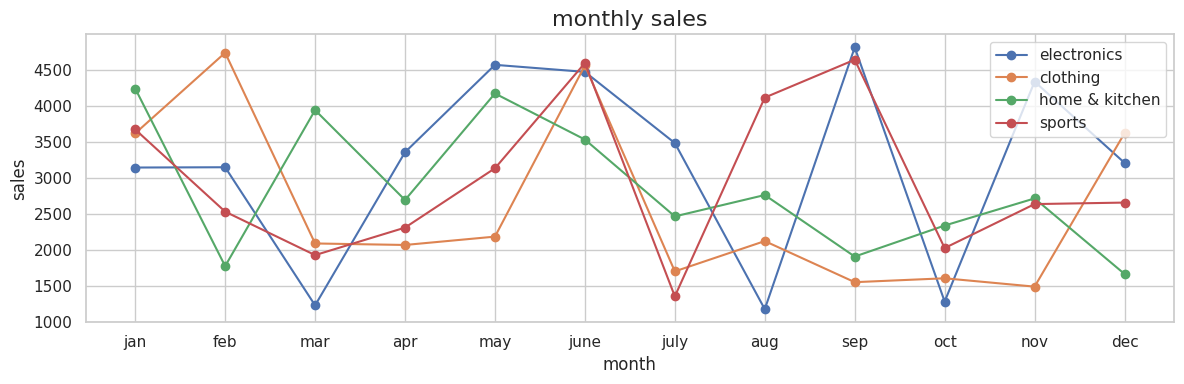

In [32]:

sns.set(style="whitegrid")
plt.figure(figsize=(12,4))
for c in colm:
    plt.plot(sales_df.index, sales_df[c], marker='o', label=c)
plt.title("monthly sales", fontsize='16')
plt.xlabel("month")
plt.ylabel("sales")
plt.tight_layout()
plt.legend()
plt.show()

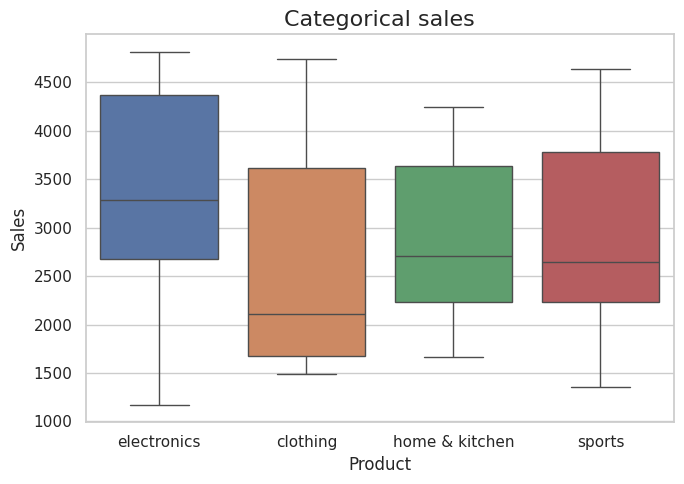

In [33]:
plt.figure(figsize=(7,5))
sns.boxplot(data=sales_df[colm])
plt.title('Categorical sales', fontsize=16)
plt.xlabel('Product')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])
    i. Find element-wise absolute value
   ii. Find the 25th, 50th, and 75th percenƟle of flaƩened array, for each column, for each row.
  iii. Mean, Median and Standard DeviaƟon of flaƩened array, of each column, and each row 

In [21]:
array = np.array([[ 1,-2, 3],
                  [-4, 5,-6]])
abs_arr = np.abs(array)
print(abs_arr)


[[1 2 3]
 [4 5 6]]


In [23]:

arr_1d = array.flatten()
percentiled = np.percentile(arr_1d, [25,50,75])
print("Flattened array perenctiles: ", percentiled)

percentiled_colm = np.percentile(array, [25,50,75], axis=0)
print("Column wise array perenctiles: ", percentiled_colm)

percentiled_row = np.percentile(array, [25,50,75], axis=1)
print("Row wise array perenctiles: ", percentiled_row)

Flattened array perenctiles:  [-3.5 -0.5  2.5]
Column wise array perenctiles:  [[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]
Row wise array perenctiles:  [[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]


In [24]:
mean_flat = np.mean(arr_1d)
median_flat = np.median(arr_1d)
std_flat = np.std(arr_1d)
print(f"Flattened arr mean:{mean_flat}, median:{median_flat}, standard dev:{std_flat}")

mean_flat = np.mean(array, axis=0)
median_flat = np.median(array, axis=0)
std_flat = np.std(array, axis=0)
print(f"Column wise arr mean:{mean_flat}, median:{median_flat}, standard dev:{std_flat}")

mean_flat = np.mean(array, axis=1)
median_flat = np.median(array, axis=1)
std_flat = np.std(array, axis=1)
print(f"Row wise arr mean:{mean_flat}, median:{median_flat}, standard dev:{std_flat}")


Flattened arr mean:-0.5, median:-0.5, standard dev:3.8622100754188224
Column wise arr mean:[-1.5  1.5 -1.5], median:[-1.5  1.5 -1.5], standard dev:[2.5 3.5 4.5]
Row wise arr mean:[ 0.66666667 -1.66666667], median:[ 1. -4.], standard dev:[2.05480467 4.78423336]


Q.3 for array : a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0])
 i. Find floor, ceiling and trunc

In [25]:
a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0])
floor_val=np.floor(a)
ceil_val=np.ceil(a)
trunc_val=np.trunc(a)
print(f"Floor vals: {floor_val}, \nceiling vals: {ceil_val}, \ntruncated vals: {trunc_val}")


Floor vals: [-2. -2. -1.  0.  1.  1.  3.], 
ceiling vals: [-1. -1. -0.  1.  2.  2.  3.], 
truncated vals: [-1. -1. -0.  0.  1.  1.  3.]


Q.4 WAP to swap two elements in a list in Python Using a Temporary Variable.

In [26]:
my_list = [10, 20, 30, 40, 50]
i = 1
j = 3
temp = my_list[i]
my_list[i] = my_list[j]
my_list[j] = temp
print("New list:", my_list)

New list: [10, 40, 30, 20, 50]


Q.5 Write a Python program to swap two elements in a set by converƟng it to a list first.

In [27]:
my_set = {10, 20, 30, 40, 50}
my_list = list(my_set)
i = 0
j = 2
temp = my_list[i]
my_list[i] = my_list[j]
my_list[j] = temp
my_set_swapped = set(my_list)
print("Set :", my_set_swapped)


Set : {40, 10, 50, 20, 30}
